In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


# 05 — Time-Series Analysis
### Early Sepsis Detection — Phase 6

Goes beyond Phase 4's simple mean-trajectory comparison to formally analyze:
mean AND median trajectories, variability (std) over time, hour-to-hour
rate of change, and measurement frequency — for sepsis-positive vs.
sepsis-negative patients.

Uses `ICULOS` as the time axis throughout, consistent with the rest of
the project. All comparisons remain descriptive — no causal or diagnostic
claims are made from these plots alone.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [3]:
# Use the RAW (pre-LOCF) long-format cache for anything measurement-frequency
# related, and the cleaned (LOCF-filled) data for trajectory-level analysis,
# since LOCF is what any model will actually see as its input signal.
raw_df = pd.read_parquet(config.INTERIM_LONG_PARQUET)
cleaned_df = pd.read_parquet(config.INTERIM_DIR / "sepsis_hourly_cleaned.parquet")

patient_label = cleaned_df.groupby(config.PATIENT_ID_COL)[config.TARGET_COL].max().rename("patient_sepsis")
cleaned_df = cleaned_df.merge(patient_label, on=config.PATIENT_ID_COL, how="left")
raw_df = raw_df.merge(patient_label, on=config.PATIENT_ID_COL, how="left")

MAX_HOUR = 72
TS_VARS = ["HR", "Resp", "Temp", "MAP", "WBC", "Lactate"]
print("Ready. Analyzing variables:", TS_VARS, "up to ICULOS =", MAX_HOUR)


Ready. Analyzing variables: ['HR', 'Resp', 'Temp', 'MAP', 'WBC', 'Lactate'] up to ICULOS = 72


## 1. Mean AND median trajectories

**What?** Phase 4 showed only the mean trajectory. Comparing mean vs.
median reveals whether a small number of extreme patients are driving the
mean (mean >> median suggests a right-skewed distribution at that hour,
common for labs like Lactate).


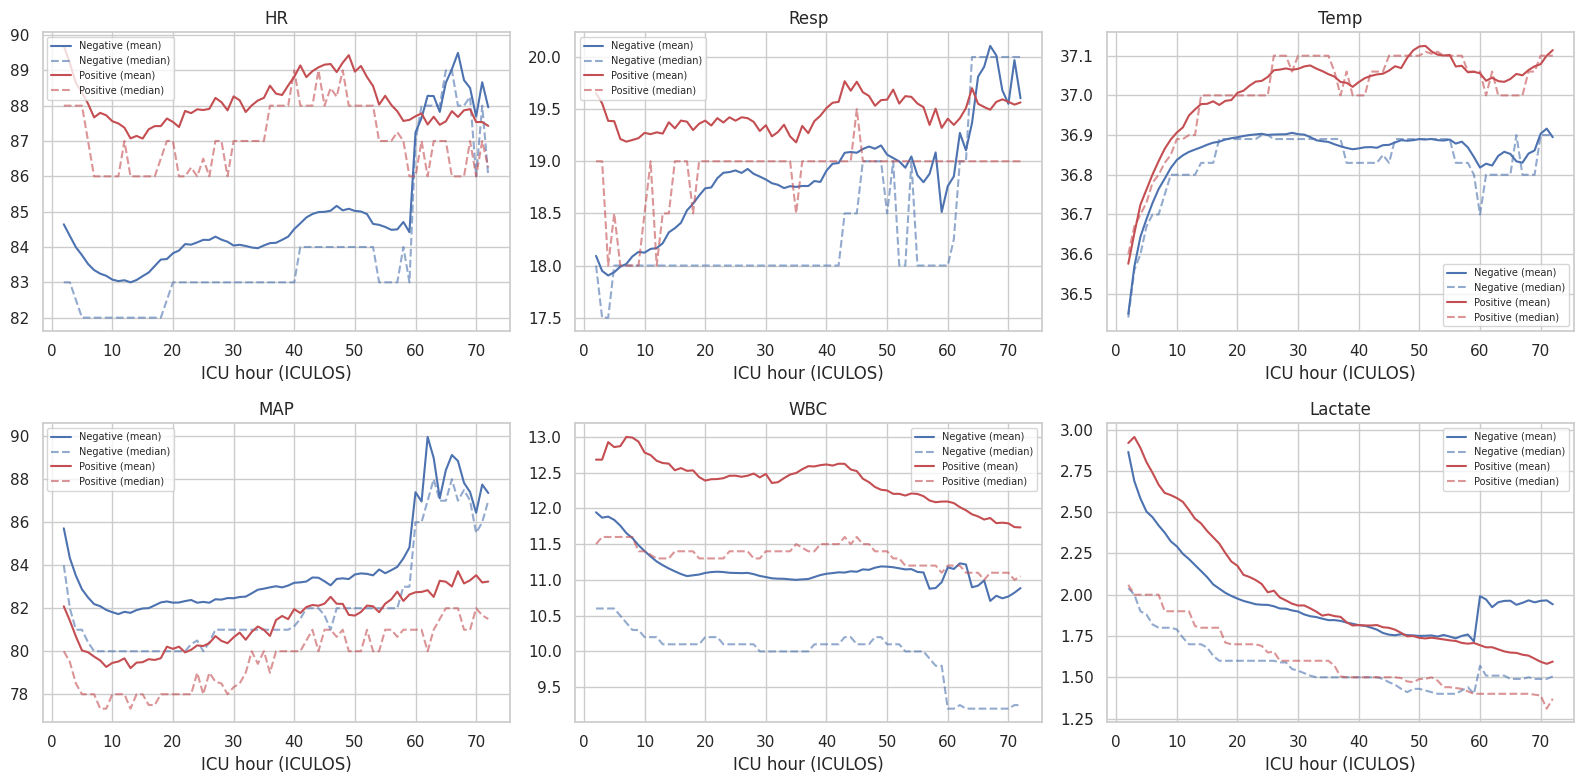

In [4]:
trend_df = cleaned_df[cleaned_df["ICULOS"] <= MAX_HOUR]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, TS_VARS):
    for label, sub in trend_df.groupby("patient_sepsis"):
        stats = sub.groupby("ICULOS")[col].agg(["mean", "median"])
        color = "#C44E52" if label == 1 else "#4C72B0"
        ax.plot(stats.index, stats["mean"], color=color, linestyle="-",
                label=f"{'Positive' if label==1 else 'Negative'} (mean)")
        ax.plot(stats.index, stats["median"], color=color, linestyle="--", alpha=0.6,
                label=f"{'Positive' if label==1 else 'Negative'} (median)")
    ax.set_title(col)
    ax.set_xlabel("ICU hour (ICULOS)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_mean_vs_median_trajectories.png", dpi=150)
plt.show()


## 2. Variability over time (standard deviation)

**What?** How much patients spread out around the mean at each ICU hour,
by sepsis status.

**Why?** Rising variability in the sepsis-positive group could indicate a
subgroup diverging sharply (e.g. some decompensating) rather than a
uniform shift — relevant for later subgroup analysis (Phase 22).


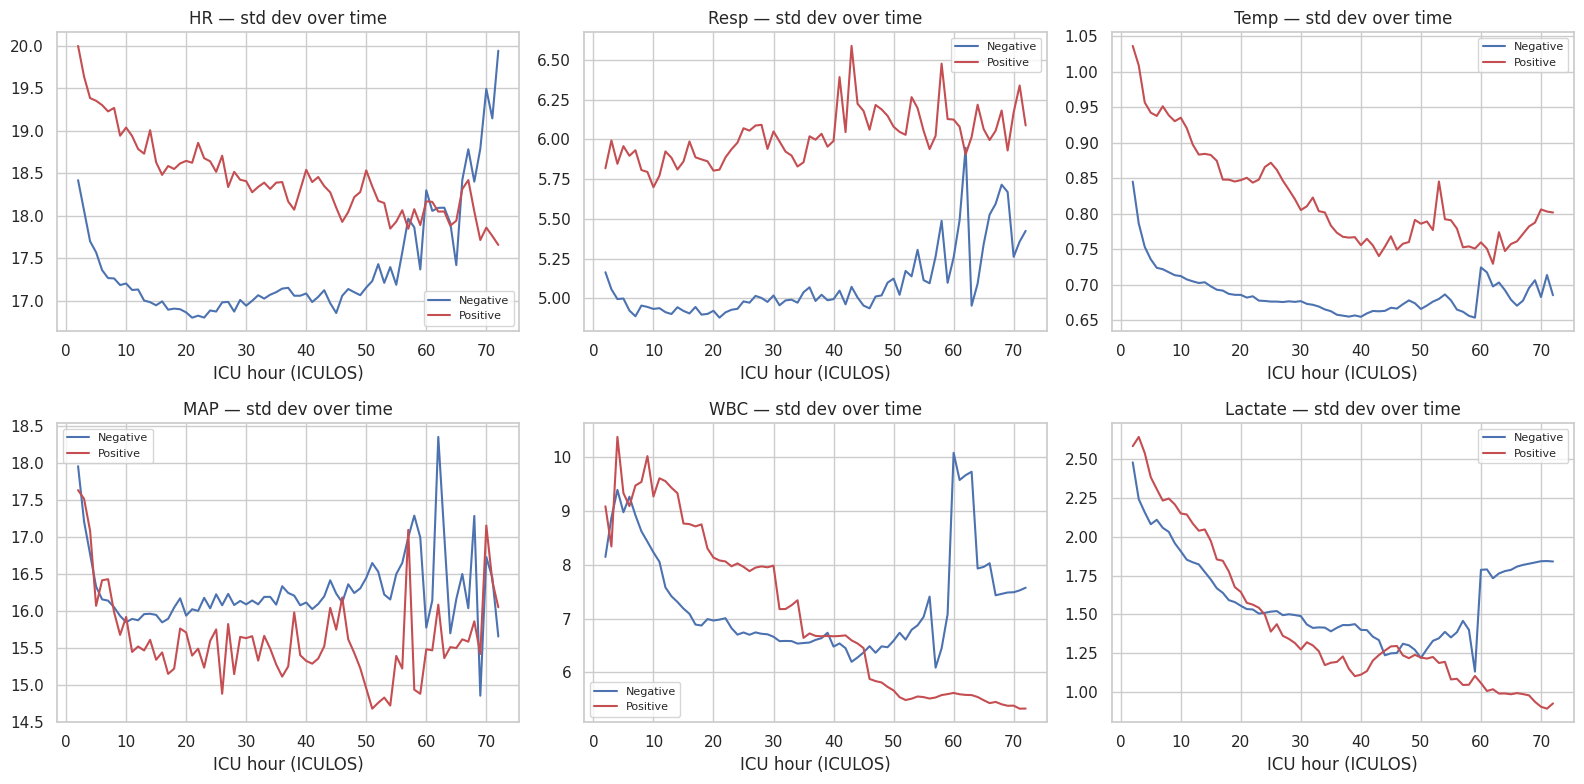

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, TS_VARS):
    for label, sub in trend_df.groupby("patient_sepsis"):
        stds = sub.groupby("ICULOS")[col].std()
        color = "#C44E52" if label == 1 else "#4C72B0"
        ax.plot(stds.index, stds.values, color=color,
                label="Positive" if label == 1 else "Negative")
    ax.set_title(f"{col} — std dev over time")
    ax.set_xlabel("ICU hour (ICULOS)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_variability_over_time.png", dpi=150)
plt.show()


## 3. Hour-to-hour rate of change

**What?** Mean absolute change between consecutive ICU hours, per patient,
averaged by group — a proxy for how "unstable" a variable is over time.

**How?** Computed as `diff()` within each patient (temporal, no leakage —
uses only that patient's own consecutive readings), then averaged by
ICULOS and sepsis status.


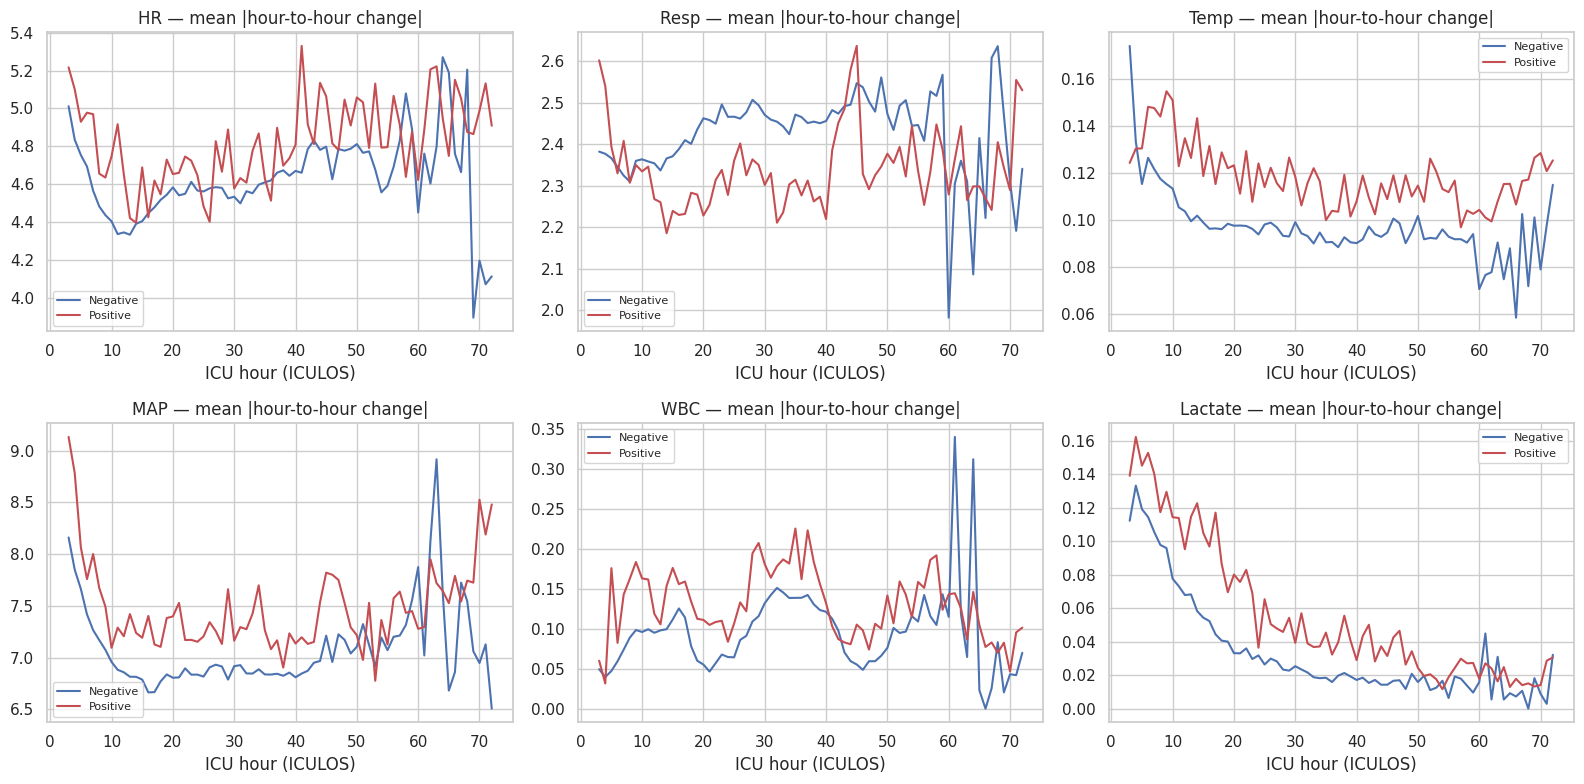

In [6]:
change_df = trend_df.sort_values([config.PATIENT_ID_COL, "ICULOS"]).copy()
for col in TS_VARS:
    change_df[f"{col}_change"] = change_df.groupby(config.PATIENT_ID_COL)[col].diff().abs()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, TS_VARS):
    change_col = f"{col}_change"
    for label, sub in change_df.groupby("patient_sepsis"):
        mean_change = sub.groupby("ICULOS")[change_col].mean()
        color = "#C44E52" if label == 1 else "#4C72B0"
        ax.plot(mean_change.index, mean_change.values, color=color,
                label="Positive" if label == 1 else "Negative")
    ax.set_title(f"{col} — mean |hour-to-hour change|")
    ax.set_xlabel("ICU hour (ICULOS)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_rate_of_change.png", dpi=150)
plt.show()


## 4. Measurement frequency comparison (recap + extension)

**What?** Extends Phase 5's finding (Lactate measured ~2.3x more often in
sepsis-positive patients) across the full first 72 hours, showing *when*
that gap opens up.


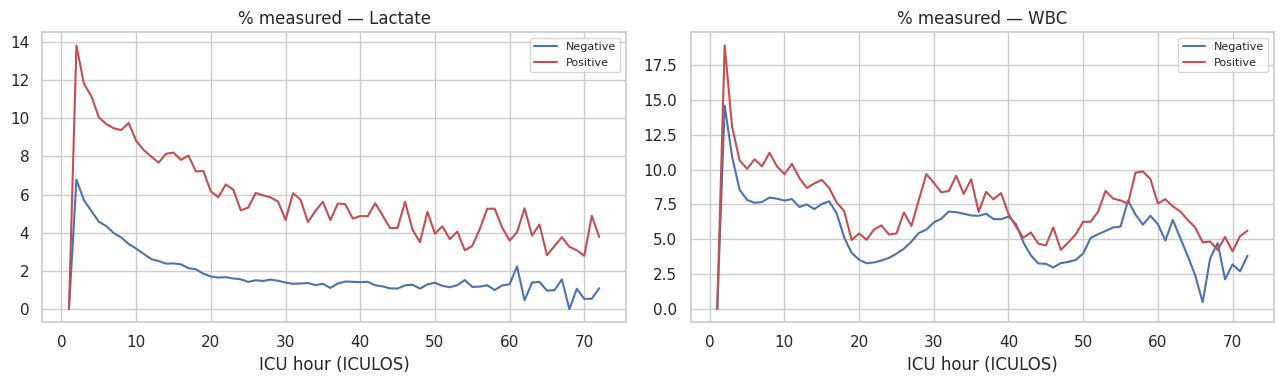

In [7]:
raw_trend = raw_df[raw_df["ICULOS"] <= MAX_HOUR]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["Lactate", "WBC"]):
    for label, sub in raw_trend.groupby("patient_sepsis"):
        measured_pct = sub.groupby("ICULOS")[col].apply(lambda s: s.notna().mean() * 100)
        color = "#C44E52" if label == 1 else "#4C72B0"
        ax.plot(measured_pct.index, measured_pct.values, color=color,
                label="Positive" if label == 1 else "Negative")
    ax.set_title(f"% measured — {col}")
    ax.set_xlabel("ICU hour (ICULOS)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_measurement_frequency_by_group.png", dpi=150)
plt.show()


## 5. Per-patient trajectory length and data density

**What?** How many actual (non-LOCF) measurements a typical patient has
per variable, and how this relates to their total ICU stay length —
important context for Phase 8's `_count` features, since a longer stay
doesn't automatically mean proportionally more measurements.


count    40336.000000
mean         0.875718
std          0.146689
min          0.000000
25%          0.860000
50%          0.923077
75%          0.956522
max          0.996503
Name: measurements_per_hour, dtype: float64


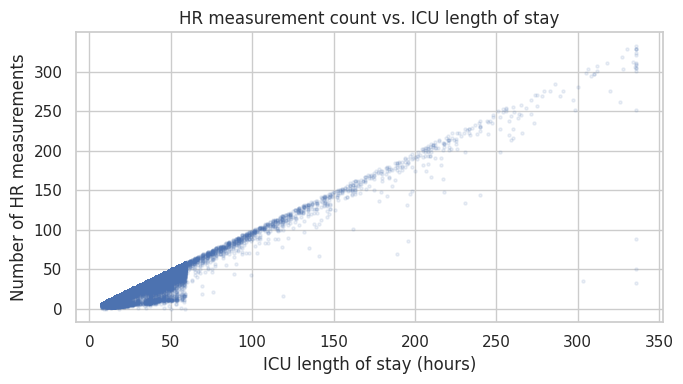

In [8]:
icu_los = raw_df.groupby(config.PATIENT_ID_COL)["ICULOS"].max()
n_hr_measurements = raw_df.groupby(config.PATIENT_ID_COL)["HR"].apply(lambda s: s.notna().sum())

density_df = pd.DataFrame({"icu_los_hours": icu_los, "n_hr_measurements": n_hr_measurements})
density_df["measurements_per_hour"] = density_df["n_hr_measurements"] / density_df["icu_los_hours"]

print(density_df["measurements_per_hour"].describe())

plt.figure(figsize=(7, 4))
plt.scatter(density_df["icu_los_hours"], density_df["n_hr_measurements"], alpha=0.1, s=5)
plt.xlabel("ICU length of stay (hours)")
plt.ylabel("Number of HR measurements")
plt.title("HR measurement count vs. ICU length of stay")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "05_measurement_density_vs_los.png", dpi=150)
plt.show()


---
### What to send back to Claude after running this notebook

- Section 1: does the mean/median gap look large for any variable (esp. Lactate)?
- Section 2: does variability rise over time in the positive group for any variable?
- Section 3: any variable where positive patients show clearly higher rate-of-change?
- Section 5's `.describe()` output for measurements_per_hour

With this, **Phase 6 is complete**, and we move to the most critical step:
**Phase 7 — Target Construction**, where we carefully verify how the official
`SepsisLabel` relates to the 6-hour-ahead prediction framing of the original
Challenge, BEFORE building any patient-level features (Phase 8), to guarantee
no future information leaks into the model.
